In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

In [21]:
# sigmoid 함수 정의
def sigmoid(x):
        return 1.0/(1.0 + np.exp(-x))

# parameter 초기값 지정
def init_network(input_dim, hidden_dim, output_dim):
    W1 = np.random.randn(input_dim, hidden_dim) # (784, 200)
    b1 = np.random.randn(hidden_dim) # bias (200,)
    W2 = np.random.randn(hidden_dim, output_dim ) # (200, 10)
    b2 = np.random.randn(output_dim) # bias (10,)
    return W1, b1, W2, b2

# 순전파
def forward(x, W1, b1, W2, b2):
    z = sigmoid(np.matmul(x, W1) - b1) # hidden activity (400, 200)
    y = sigmoid(np.matmul(z, W2) - b2) # 출력값 y를 predict (400, 10)
    return z, y

# 역전파
def backward(x, true_y, W1, b1, W2, b2, lr=0.01): # lr는 learning rate
    z, y = forward(x, W1, b1, W2, b2) # prediction구하기 (이걸 구해야 에러를 구할 수 있음)
    """
    z = sigmoid(x*w1-b1) = sigmoid(s1)
    s1 = x*w1-b1
    y = sigmoid(z*w2-b2) = sigmoid(s2)
    s2 = z*w2-b2 
    
    dLdw2 = dLdy * dyds2 * ds2dw2 =  -(y_true-y) *  y(1-y) * z = error_y * z 
    dLdb2 = dLdy * dyds2 * ds2db2 =  -(y_true-y) *  y(1-y) * (-1) = error_y * (-1)
    dLdw1 = dLdy * dyds2 * ds2dz * dzds1 * ds1dw1 = -(y_true-y) *  y(1-y) * w2 * z(1-z) * x = error_z * x
    dLdb1 = dLdy * dyds2 * ds2dz * dzds1 * ds1db1 = -(y_true-y) *  y(1-y) * w2 * z(1-z) * (-1) = error_z * (-1)
    
    error_y = -(y_true-y) *  y(1-y)
    error_z = error_y * w2 * z(1-z) 
    """
    error_y = (true_y - y)*y*(1-y) # (400, 10) * (400, 10) * (400, 10) = (400, 10)
    error_z = error_y.dot(W2.T)*z*(1-z) # ((400, 10) * (10, 200)) * (400, 200) * (400, 200) = (400, 200)
    
    dLdW2 = np.matmul(z.T, error_y) # (200, 400) * (400, 10) = (200, 10)
    dLdW1 = np.matmul(x.T, error_z) # (784, 400) * (400, 200) = (784, 200)
    dLdb2 = np.sum(error_y,axis=0)*(-1.) # (400, 10)을 열 방향으로 합치면 (10,)
    dLdb1 = np.sum(error_z,axis=0)*(-1.) # (400, 200)을 열 방향으로 합치면 (200,)
    
    W2 = W2 + lr * dLdW2
    W1 = W1 + lr * dLdW1
    b2 = b2 + lr * dLdb2
    b1 = b1 + lr * dLdb1
    
    return W1, b1, W2, b2

In [ ]:
# load data
mnist = fetch_openml('mnist_784') # 손글씨 데이터
samples, labels = mnist.data, mnist.target # data: 28x28 이미지, target: true label
samples = samples.values/255 # 픽셀은 255까지의 숫자를 갖고 있는데 0~1사이 값을 가지도록 정규화 (에러나서 주석처리)

In [28]:
# one-hot encoding
# 출력을 정수로 쓰면 에러 구할 때 출력을 모두 동등하게 생각하지 않게 됨
# 반면 원핫인코딩은 인코딩 자체가 모두 동등
one_hot_labels = np.zeros([sample_num,10]) # 샘플 개수만큼 0을 집어 넣음 (N행 10열)

# 각 샘플에서 라벨이 있는 자릿수에만 1을 넣음
for i in range(sample_num):
    one_hot_labels[i, int(labels[i])] = 1.

print(labels[0]) # 정수 표현
print(one_hot_labels[0]) # 원핫인코딩 표현

5
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [35]:
samples.shape

(70000, 784)

In [36]:
labels.shape

(70000,)

Label: 4, one_hot_encoding: [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.].
(784,)
(28, 28)


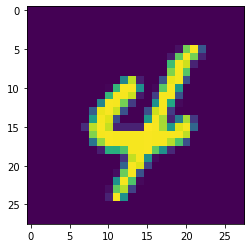

In [37]:
# 데이터 확인하기
index = 139 # 0 to 69999 중 아무 숫자
img = samples[index,:] # :은 한 이미지에서 모든 픽셀을 표현하라는 의미
print( 'Label: %s, one_hot_encoding: %s.'%(labels[index], one_hot_labels[index,:]) )

print(img.shape)
img = img.reshape(28,28)
print(img.shape)

plt.imshow(img)
plt.show()

epoch: 0/200, error: 275/400
epoch: 10/200, error: 180/400
epoch: 20/200, error: 137/400
epoch: 30/200, error: 149/400
epoch: 40/200, error: 138/400
epoch: 50/200, error: 128/400
epoch: 60/200, error: 129/400
epoch: 70/200, error: 139/400
epoch: 80/200, error: 132/400
epoch: 90/200, error: 136/400
epoch: 100/200, error: 144/400
epoch: 110/200, error: 122/400
epoch: 120/200, error: 130/400
epoch: 130/200, error: 134/400
epoch: 140/200, error: 118/400
epoch: 150/200, error: 130/400
epoch: 160/200, error: 126/400
epoch: 170/200, error: 118/400
epoch: 180/200, error: 125/400
epoch: 190/200, error: 127/400


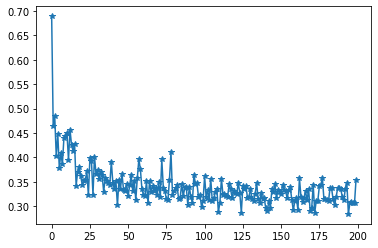

In [38]:
# parameter
batch_size = 400 # 전체 데이터를 넣지 말고 한 번에 임의의 400개씩만 뽑아서 넣음 -> SGD 사용. local에 빠지지 않도록
epoch_num = 200

# 초기값 지정
W1, b1, W2, b2 = init_network(input_dim=784, hidden_dim=200, output_dim=10)
epoch_dat = []
error_dat = []

# train
# 그냥 7만개 중에 200 샘플을 뽑는 게 아니라, 전체 7만장 중에 400개씩 뽑을 수 있는 횟수, 즉 7만/400번만큼 업데이트 하는 것을 한 epoch로 봄
for epoch in range(epoch_num):
    
    for a in range(int(sample_num/batch_size)):
        
        start = np.random.randint(50000)
        x = samples[start:start+batch_size, :] # 다른 방법으로 400개를 뽑을 수도 있음
        x = x.reshape(x.shape[0],784) # (400, 784)
        true_y = one_hot_labels[start:start+batch_size,:] # 동일한 인덱스

        W1, b1, W2, b2 = backward(x, true_y, W1, b1, W2, b2, lr=0.02)
        z, y = forward(x, W1, b1, W2, b2)
        train_error = np.sum(np.abs(true_y - y))
    
    epoch_dat.append(epoch)
    error_dat.append(train_error/batch_size)        
    
    if epoch % 10 == 0: # 10 epoch마다 error rate를 표시하도록
        print( 'epoch: %d/%d, error: %d/%d'%(epoch, epoch_num, train_error, batch_size))

plt.plot(epoch_dat, error_dat, '-*')
plt.show()

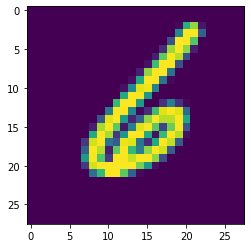

true_label = 6, predicted_label =4


In [39]:
# prediction
index = 999 # 아무 이미지나 뽑기
img = samples[index,:]
true_label = labels[index]

plt.imshow(img.reshape(28,28))
plt.show()

x = img.reshape(784)
z, y = forward(x, W1, b1, W2, b2) # 학습된 파라미터를 가지고 y를 prediction
print('true_label = %s, predicted_label =%d' %(true_label, np.argmax(y))) # 원핫인코딩이므로 출력값에서 가장 큰 값을 가진 것, 즉 1인 것에 해당하는 값을 알려줌 -> argmax

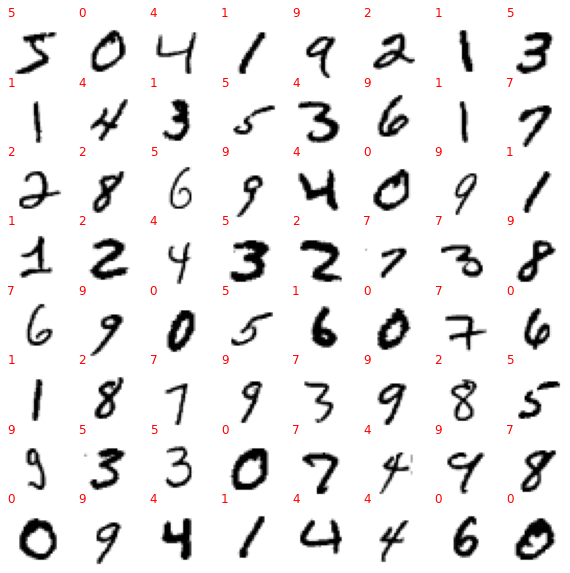

In [45]:
# 한 번에 여러 개 prediction
imgs = samples[0:64]
x = imgs.reshape(imgs.shape[0],784)
z, y = forward(x, W1, b1, W2, b2)
label_pred = np.argmax(y, axis=1)

figure = plt.figure(figsize=(10,10))
num_of_images = 64
for index in range(1,num_of_images+1):
    plt.subplot(8, 8, index)
    plt.imshow(x[index-1].reshape(28,28),cmap='gray_r')
    plt.axis('off')
    plt.title('{}'.format(label_pred[index-1]),loc='left',color='r')    